In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv('Loans.csv')
dataset.head(3)

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT


In [3]:
dataset.isnull().sum()

customer_id                3
customer_age               0
customer_income            0
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20737
cred_hist_length           0
Current_loan_status        4
dtype: int64

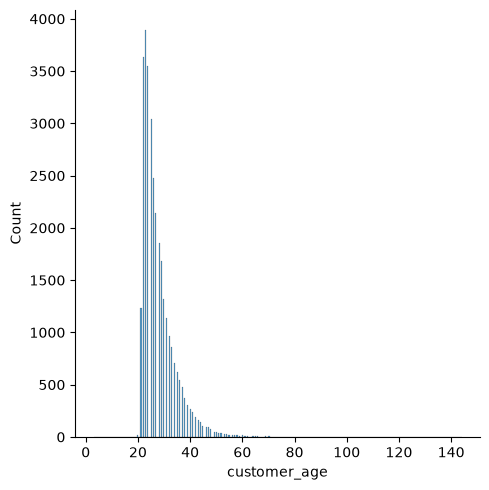

In [10]:
sns.displot(dataset["customer_age"])

In [5]:
from sklearn.preprocessing import StandardScaler

In [7]:
dataset.describe()

,customer_id,customer_age,employment_duration,loan_int_rate,term_years,cred_hist_length
count,32583.000000,32586.000000,31691.000000,29470.000000,32586.000000,32586.000000
mean,16289.497806,27.732769,4.790161,11.011553,4.761738,5.804026
std,9405.919628,6.360528,4.142746,3.240440,2.471107,4.055078
min,1.000000,3.000000,0.000000,5.420000,1.000000,2.000000
25%,8144.500000,23.000000,2.000000,7.900000,3.000000,3.000000
50%,16288.000000,26.000000,4.000000,10.990000,4.000000,4.000000
75%,24433.500000,30.000000,7.000000,13.470000,7.000000,8.000000
max,32581.000000,144.000000,123.000000,23.220000,10.000000,30.000000


In [9]:
dataset.dtypes

customer_id            float64
customer_age             int64
customer_income         object
home_ownership          object
employment_duration    float64
loan_intent             object
loan_grade              object
loan_amnt               object
loan_int_rate          float64
term_years               int64
historical_default      object
cred_hist_length         int64
Current_loan_status     object
dtype: object

In [11]:
ss=StandardScaler()
ss.fit(dataset[["customer_age"]])

,copy,True
,with_mean,True
,with_std,True


In [17]:
dataset["customer_age_ss"]= pd.DataFrame(ss.transform(dataset[["customer_age"]]),columns=["x"])
dataset.head(3)

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,customer_age_ss
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT,-0.901318
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT,-1.058540
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT,-0.429652


In [18]:
dataset.describe()

,customer_id,customer_age,employment_duration,loan_int_rate,term_years,cred_hist_length,customer_age_ss
count,32583.000000,32586.000000,31691.000000,29470.000000,32586.000000,32586.000000,3.258600e+04
mean,16289.497806,27.732769,4.790161,11.011553,4.761738,5.804026,1.116424e-16
std,9405.919628,6.360528,4.142746,3.240440,2.471107,4.055078,1.000015e+00
min,1.000000,3.000000,0.000000,5.420000,1.000000,2.000000,-3.888537e+00
25%,8144.500000,23.000000,2.000000,7.900000,3.000000,3.000000,-7.440957e-01
50%,16288.000000,26.000000,4.000000,10.990000,4.000000,4.000000,-2.724295e-01
75%,24433.500000,30.000000,7.000000,13.470000,7.000000,8.000000,3.564588e-01
max,32581.000000,144.000000,123.000000,23.220000,10.000000,30.000000,1.827978e+01


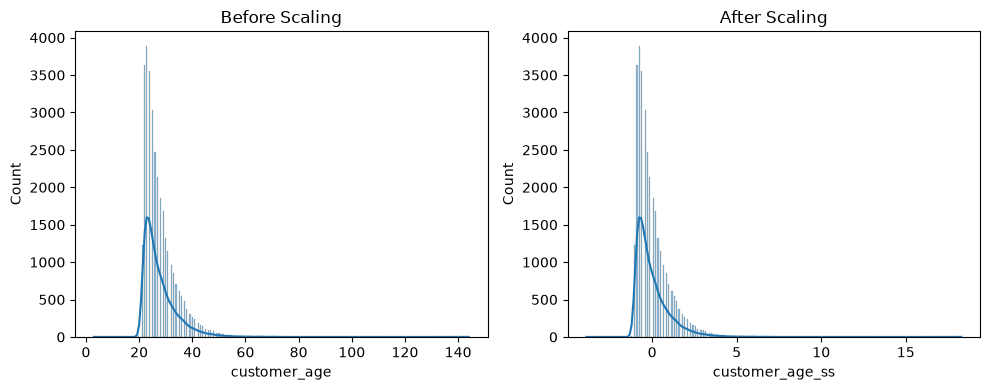

In [30]:
plt.figure(figsize=(10, 4))

# Before Scaling
plt.subplot(1, 2, 1)
plt.title("Before Scaling")
sns.histplot(dataset["customer_age"], kde=True)

# After Scaling
plt.subplot(1, 2, 2)
plt.title("After Scaling")
sns.histplot(dataset["customer_age_ss"], kde=True)

plt.tight_layout()
plt.show()

Normalization Scaling Technique

<Axes: xlabel='term_years', ylabel='Count'>

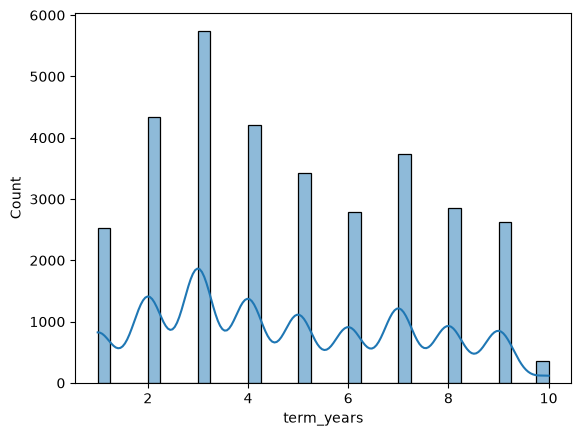

In [42]:
sns.histplot(dataset["term_years"],kde=True)


In [47]:
from sklearn.preprocessing import MinMaxScaler

In [48]:
ms=MinMaxScaler()
ms.fit(dataset[["term_years"]])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [59]:
dataset["term_years__ms"] = pd.DataFrame(ms.transform(dataset[["term_years"]]))
dataset.head(3)

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,customer_age_ss,term_years__ms
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT,-0.901318,1.000000
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT,-1.058540,0.000000
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT,-0.429652,0.444444


<Axes: title={'center': 'After'}, xlabel='term_years__ms', ylabel='Count'>

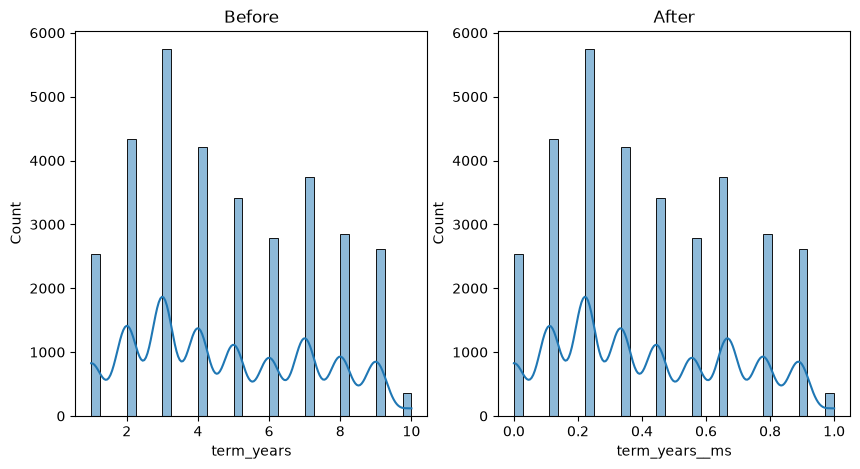

In [68]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Before")
sns.histplot(dataset["term_years"], kde=True)

plt.subplot(1,2,2)
plt.title("After")
sns.histplot(dataset["term_years__ms"], kde=True)
